In [3]:
# Datos
import pandas as pd

datos = {
    'Nombre': ['Ana', 'Juan', 'María', 'Carlos', 'Laura', 'Pedro', 'Sofía', 'Diego', 'Isabel', 'Mateo', 'Lucía', 'Javier', 'Carmen', 'Raúl', 'Elena'],
    'Mates': [85, 78, 92, 65, 88, 76, 95, 70, 82, 90, 73, 87, 79, 93, 68]
}

df_notas = pd.DataFrame(datos)
df_notas.set_index('Nombre', inplace=True)

# Ejemplo de cómo acceder a los datos
df_notas.head(5)

,Mates
Nombre,
Ana,85
Juan,78
María,92
Carlos,65
Laura,88


# Ejercicio 1


Cálculo de estadísticas:

+ Calcula la media, la mediana, la moda, la varianza y la desviación estándar de las notas.
+ Calcula el percentil 25, el percentil 50 (mediana) y el percentil 75 de las notas.

Creación de histograma:
+ Crea un histograma que muestre la distribución de las notas.
+ Añade líneas verticales para marcar la media, la mediana y los percentiles calculados.
+ Añade zona para marcar media+-1std
+ Añade etiquetas y un título al gráfico.

Análisis:
+ Comenta la forma de la distribución de las notas.
+ Identifica si hay valores atípicos.
+ Compara la media y la mediana y explica qué indica la diferencia entre ellas.

Estadísticas básicas:
Media: 81.40
Mediana: 82.00
Moda: 65.00
Varianza: 92.11
Desv. Estándar: 9.60
Percentiles 25, 50, 75: [74.5 82.  89. ]


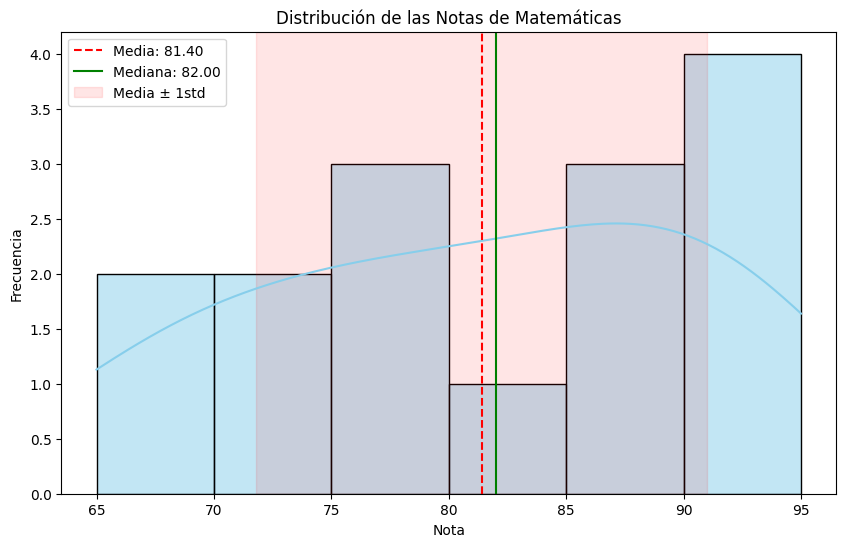

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Cálculo de estadísticas ---
notas = df_notas['Mates']
stats = {
    "Media": notas.mean(),
    "Mediana": notas.median(),
    "Moda": notas.mode()[0],
    "Varianza": notas.var(),
    "Desv. Estándar": notas.std()
}
percentiles = np.percentile(notas, [25, 50, 75])

print("Estadísticas básicas:")
for k, v in stats.items(): print(f"{k}: {v:.2f}")
print(f"Percentiles 25, 50, 75: {percentiles}")

# --- 2. Histograma ---
plt.figure(figsize=(10, 6))
sns.histplot(notas, kde=True, bins=6, color='skyblue')

# Líneas estadísticas
plt.axvline(stats["Media"], color='red', linestyle='--', label=f'Media: {stats["Media"]:.2f}')
plt.axvline(stats["Mediana"], color='green', linestyle='-', label=f'Mediana: {stats["Mediana"]:.2f}')
plt.axvspan(stats["Media"] - stats["Desv. Estándar"], stats["Media"] + stats["Desv. Estándar"], 
            color='red', alpha=0.1, label='Media ± 1std')

plt.title('Distribución de las Notas de Matemáticas')
plt.xlabel('Nota')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# Ejercicio 2

Cálculo de cuartiles:
+ Calcula el primer cuartil (Q1), el segundo cuartil (Q2 o mediana) y el tercer cuartil (Q3) de las notas.

Creación de gráfico de barras:

+ Crea un gráfico de barras que muestre las notas de cada alumno.
+ Ordena las barras (o los datos) para que se vean por nota de forma descendente.
+ Añade una línea horizontal para marcar la mediana de las notas.
+ Añade un rectángulo que marque media+-1std.
+ Añade etiquetas y un título al gráfico.

Análisis:

+ Identifica qué alumnos están por encima y por debajo de la mediana.
+ Comenta la dispersión de las notas en relación con los cuartiles.
+ Explica qué información proporciona el gráfico de barras en comparación con el histograma del ejercicio anterior.

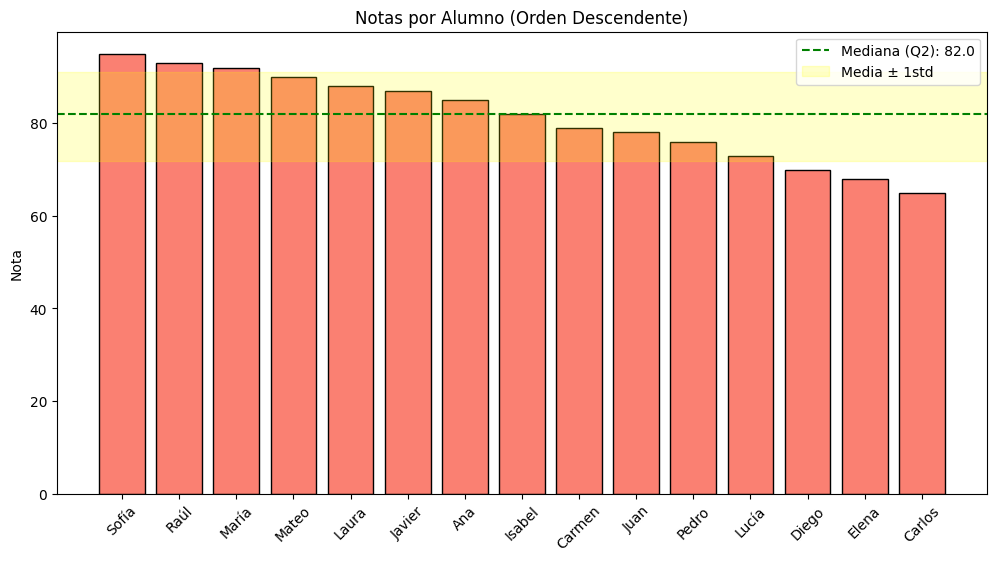

In [5]:
# --- 1. Cálculo de cuartiles ---
q1, q2, q3 = np.percentile(notas, [25, 50, 75])

# --- 2. Gráfico de barras ordenado ---
df_sorted = df_notas.sort_values(by='Mates', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(df_sorted.index, df_sorted['Mates'], color='salmon', edgecolor='black')

# Línea de mediana
plt.axhline(q2, color='green', linestyle='--', label=f'Mediana (Q2): {q2}')

# Rectángulo Media ± 1std
lower_bound = stats["Media"] - stats["Desv. Estándar"]
upper_bound = stats["Media"] + stats["Desv. Estándar"]
plt.axhspan(lower_bound, upper_bound, color='yellow', alpha=0.2, label='Media ± 1std')

plt.xticks(rotation=45)
plt.title('Notas por Alumno (Orden Descendente)')
plt.ylabel('Nota')
plt.legend()
plt.show()